# Where the odorant panel sits in natural-product chemical space

Four questions the receptor analysis raises but cannot answer on its own, asked against the
COCONUT universe built by `chemspace/`:

1. Do the six co-tuning clusters occupy distinct regions of natural-product space, or interleave?
2. Is volatility (`Tb_joback`) different between clusters?
3. Is natural-product likeness different between clusters?
4. Where do Class I- and Class II-preferring odorants sit?

The UMAP is of **natural-product space**, not odour space. Its axes have no perceptual reading,
so positions are described as *regions* — never "islands", which is reserved for the kNN
enrichment result in `chemspace/`.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from collections import Counter
from scipy.spatial.distance import pdist, squareform
from scipy.stats import kruskal, mannwhitneyu

sys.path.append("chemspace")
sys.path.append("../Downstream_Analysis/scripts")
import chemspace as cs
from calibration import fit_calibration_map, density_fill

# --- EDIT HERE -------------------------------------------------------------------
# Point at whichever universe you want. Default is our 08-2026 rebuild; fall back to the
# 07-2026 run while the GPU pipeline is still going.
# Defaults to the in-repository pipeline output. Set CHEMSPACE_RESULTS to point
# somewhere else (an older run, a shared scratch directory) without editing this.
RESULTS = Path(os.environ.get("CHEMSPACE_RESULTS", "chemspace/results"))
if not (RESULTS / "universe.parquet").exists():
    raise FileNotFoundError(
        f"No universe.parquet under {RESULTS}. Build it with\n"
        f"    cd chemspace && python s01_build_universe.py && python s02_embed.py\n"
        f"or set CHEMSPACE_RESULTS to a directory that already has one."
    )
# ---------------------------------------------------------------------------------

PROB  = "../Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
PAIRS = "../Model/Data_Preparation/processed/m2or_pairs_model.csv"
FASTA = "../Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = "../Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
FIG = Path("chemspace/figures"); FIG.mkdir(parents=True, exist_ok=True)

K, N_INIT = 6, 6000
CLASS_I_COL, CLASS_II_COL, SHARED_COL = "#7f1734", "#557c99", "#9a8f80"
INK, MUTED, GRID = "#3f3f3c", "#8a8a86", "#e8e8e4"
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 170, "font.size": 9,
                     "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.edgecolor": "#bbbbb8",
                     "axes.spines.top": False, "axes.spines.right": False})
print("reading universe from", RESULTS)

reading universe from chemspace/results


## 1 · The universe and its map

In [2]:
uni = pd.read_parquet(RESULTS / "universe.parquet")
idx = pd.read_csv(RESULTS / "embed_index.csv")
uni = uni.set_index("inchikey").loc[idx.inchikey].reset_index()
xy = np.load(RESULTS / "umap.npy")
assert len(xy) == len(uni), "umap and universe are out of alignment"
print(f"universe {uni.shape}   odorants {int(uni.is_odorant.sum())}   "
      f"M2OR panel {int(uni.in_m2or.sum())}")

universe (726407, 57)   odorants 5962   M2OR panel 754


## 2 · The receptor side: clusters and receptor class

Rebuilt here rather than read from a file, so this notebook cannot silently drift from
`reference_tree/02`: same density fill, same Jaccard + PAM at k = 6, same seed and `n_init`.

In [3]:
prob = pd.read_csv(PROB, index_col=0)
hum_pids = [i for i in prob.index if str(i).startswith("9606")]
P = prob.loc[hum_pids]; lig_cols = list(P.columns); Pv = P.values

pid2seq, pid, buf = {}, None, []
for line in open(FASTA):
    line = line.rstrip()
    if line.startswith(">"):
        if pid: pid2seq[pid] = "".join(buf).upper()
        pid, buf = line[1:].split()[0], []
    else: buf.append(line)
if pid: pid2seq[pid] = "".join(buf).upper()
seq2pid = {}
for p in hum_pids: seq2pid.setdefault(pid2seq[p], []).append(p)

m = pd.read_csv(PAIRS, usecols=["Species","UniProt ID","Sequence","Responsive","smiles_id","mutation"])
hs = m[m["Species"].str.lower().str.contains("homo")].copy()
hs["Sequence"] = hs["Sequence"].str.upper().str.strip()
hs["pid"] = hs["Sequence"].map(lambda s: seq2pid.get(s, [None])[0])
exp = (hs[hs["pid"].notna() & hs["smiles_id"].isin(set(lig_cols))]
       .groupby(["pid","smiles_id"])["Responsive"].max().reset_index())
ridx = {p:i for i,p in enumerate(hum_pids)}; cidx = {c:j for j,c in enumerate(lig_cols)}
rr = np.array([ridx[p] for p in exp["pid"]]); cc = np.array([cidx[c] for c in exp["smiles_id"]])
yv = exp["Responsive"].values.astype(int)
tested = np.zeros(Pv.shape, bool); tested[rr,cc] = True
E = np.zeros(Pv.shape, np.int8); E[rr,cc] = yv
FILL = density_fill(Pv, fit_calibration_map(Pv[rr,cc], yv), tested, E)
X = FILL.matrix.astype(int)
print(f"matrix density {FILL.density:.4%}  cut {FILL.cut:.4f} (output)")


def kmedoids(D, k, n_init=N_INIT, seed=0):
    rng = np.random.default_rng(seed); n = len(D); best = None
    for _ in range(n_init):
        med = rng.choice(n, k, replace=False)
        for _ in range(300):
            lab = D[:, med].argmin(1); nm = med.copy()
            for c in range(k):
                ii = np.where(lab == c)[0]
                if len(ii): nm[c] = ii[D[np.ix_(ii, ii)].sum(1).argmin()]
            if set(nm) == set(med): med = nm; break
            med = nm
        lab = D[:, med].argmin(1); cost = D[np.arange(n), med[lab]].sum()
        if best is None or cost < best[0]: best = (cost, lab.copy())
    return best


cols = np.array(lig_cols); keep = X.sum(0) > 0
lig, Xn = cols[keep], X[:, keep]
Dj = np.nan_to_num(squareform(pdist(Xn.T, "jaccard")))
cost, lab = kmedoids(Dj, K)
print(f"clusters cost {cost:.4f}  sizes {sorted(Counter(lab).values(), reverse=True)}")

# receptor-class partition of the odorants, r = 1/62 as in 02
cls = pd.read_csv(CLASSES)
pid2class = {r.leaf_id: ("I" if r.OR_class.split("_")[1] == "I" else "II") for r in cls.itertuples()}
isI = np.array([pid2class[p] == "I" for p in hum_pids])
NI, NII = isI.sum(), (~isI).sum()
rI = X[isI][:, keep].sum(0) / NI
rII = X[~isI][:, keep].sum(0) / NII
r0 = 1.0 / NI
grp = np.where((rI >= r0) & (rII < r0), "Class I only",
      np.where((rI >= r0) & (rII >= r0), "shared",
      np.where((rI < r0) & (rII >= r0), "Class II only", "")))
print("class partition:", {k: int((grp == k).sum()) for k in ["Class I only","shared","Class II only"]},
      " below r in both:", int((grp == "").sum()))

matrix density 2.7453%  cut 0.8917 (output)


clusters cost 328.9871  sizes [214, 127, 108, 100, 70, 68]
class partition: {'Class I only': 111, 'shared': 276, 'Class II only': 112}  below r in both: 188


## 3 · Joining panel to universe

The universe is keyed by an InChIKey that `chemspace.to_parent` recomputes from SMILES after
desalting. The panel key must be built the same way — using the InChIKey shipped in
`inchi_odors_smiles.csv` would silently miss the desalted and re-canonicalised cases.

In [4]:
pairs = pd.read_csv(PAIRS, usecols=["SMILES","smiles_id"])
sml2smiles = pairs.drop_duplicates("smiles_id").set_index("smiles_id")["SMILES"].to_dict()

rows = []
for i, s in enumerate(lig):
    r = cs.to_parent(sml2smiles.get(s) or "")
    rows.append({"smiles_id": s, "cluster": int(lab[i]), "class_group": grp[i],
                 "inchikey": r[1] if r else None})
panel = pd.DataFrame(rows)

u_small = uni[["inchikey"]].copy()
u_small["row"] = np.arange(len(uni))
panel = panel.merge(u_small, on="inchikey", how="left")
panel["in_universe"] = panel["row"].notna()

print(f"clustered ligands            : {len(panel)}")
print(f"  InChIKey resolved          : {int(panel.inchikey.notna().sum())}")
print(f"  matched into the universe  : {int(panel.in_universe.sum())}")
for c in ["Tb_joback", "np_likeness", "np_classifier_pathway"]:
    if c in uni:
        got = panel.loc[panel.in_universe, "row"].astype(int)
        n = pd.to_numeric(uni[c].iloc[got], errors="coerce").notna().sum() if c != "np_classifier_pathway" \
            else uni[c].iloc[got].notna().sum()
        print(f"  with {c:22s}: {int(n)}")

panel.to_csv("chemspace/panel_universe_join.csv", index=False)
P_ = panel[panel.in_universe].copy()
P_["row"] = P_["row"].astype(int)
P_["x"] = xy[P_["row"], 0]; P_["y"] = xy[P_["row"], 1]
for c in ["Tb_joback", "np_likeness", "logP_vap", "np_classifier_pathway"]:
    if c in uni: P_[c] = uni[c].values[P_["row"]]
print(f"\npanel molecules with map coordinates: {len(P_)}")

clustered ligands            : 687
  InChIKey resolved          : 687
  matched into the universe  : 687
  with Tb_joback             : 686
  with np_likeness           : 486
  with np_classifier_pathway : 442

panel molecules with map coordinates: 687


## 4 · Where the six clusters sit

If the clusters occupied distinct regions, co-tuning would be tracking a coarse split of
natural-product chemistry. If they interleave, the receptor code is cutting across it.

In [5]:
XY = P_[["x", "y"]].values; cl = P_.cluster.values
within, between = [], []
for c in range(K):
    ii = np.flatnonzero(cl == c); jj = np.flatnonzero(cl != c)
    within.append(np.median(pdist(XY[ii])) if len(ii) > 1 else np.nan)
    between.append(np.median(np.linalg.norm(XY[ii][:, None, :] - XY[jj][None, :, :], axis=2)))
print("within / between UMAP distance computed for", K, "clusters")

within / between UMAP distance computed for 6 clusters


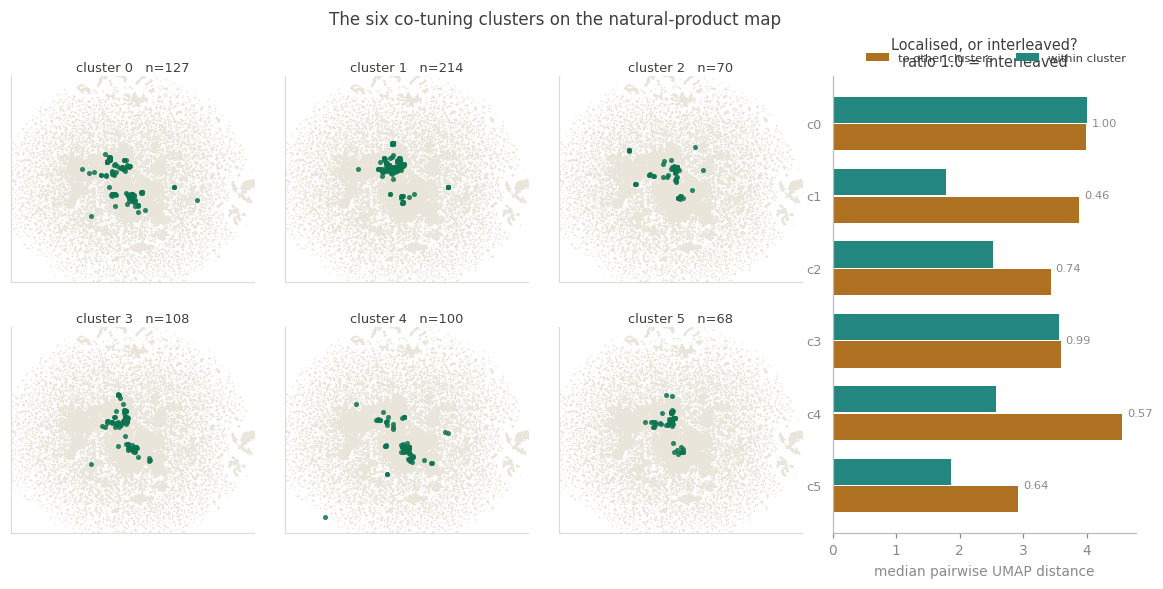

median within / between UMAP distance per cluster
  cluster 0:   4.00  vs   3.99   ratio 1.00
  cluster 1:   1.78  vs   3.88   ratio 0.46
  cluster 2:   2.53  vs   3.43   ratio 0.74
  cluster 3:   3.56  vs   3.59   ratio 0.99
  cluster 4:   2.58  vs   4.55   ratio 0.57
  cluster 5:   1.86  vs   2.92   ratio 0.64


In [6]:
# Six categories cannot be told apart as overlaid scatter points -- no palette clears the
# colour-vision floors at six slots, so identity goes to panel position instead of hue and
# each facet needs only one colour. It also answers the question better: you can see each
# cluster's footprint rather than a single confetti plot.
THEME = ["#543005", "#ae7121", "#c8923b", "#98d7cd", "#24877f", "#003c30"]
ODOR = "#0b7350"
sub = np.random.default_rng(0).choice(len(xy), min(120_000, len(xy)), replace=False)
xlim = (np.percentile(xy[:,0], 0.2), np.percentile(xy[:,0], 99.8))
ylim = (np.percentile(xy[:,1], 0.2), np.percentile(xy[:,1], 99.8))

fig = plt.figure(figsize=(13.2, 5.4))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.25], hspace=0.22, wspace=0.12)

for c in range(K):
    ax = fig.add_subplot(gs[c // 3, c % 3])
    ax.scatter(xy[sub,0], xy[sub,1], s=0.7, c="#e9e5db", alpha=0.5, lw=0, rasterized=True)
    m = P_.cluster == c
    ax.scatter(P_.x[m], P_.y[m], s=11, c=ODOR, alpha=0.85, lw=0, rasterized=True)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"cluster {c}   n={int(m.sum())}", fontsize=8.5, color=INK, pad=3)
    for sp in ax.spines.values(): sp.set_edgecolor("#dcdcd8")

ax = fig.add_subplot(gs[:, 3])
xx = np.arange(K)
ax.barh(xx + 0.19, between, height=0.36, color="#ae7121", label="to other clusters")
ax.barh(xx - 0.19, within, height=0.36, color="#24877f", label="within cluster")
for c in range(K):
    ax.text(max(within[c], between[c]) + 0.08, c, f"{within[c]/between[c]:.2f}",
            va="center", fontsize=7.5, color=MUTED)
ax.set_yticks(xx); ax.set_yticklabels([f"c{c}" for c in range(K)], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("median pairwise UMAP distance")
ax.set_title("Localised, or interleaved?\nratio 1.0 = interleaved", fontsize=9.5, color=INK)
ax.legend(frameon=False, fontsize=7.5, ncol=2, loc="lower right",
          bbox_to_anchor=(1.0, 1.005), labelcolor=INK)
ax.tick_params(left=False)

fig.suptitle("The six co-tuning clusters on the natural-product map", fontsize=11, color=INK, y=0.99)
plt.savefig(FIG / "X1_clusters_in_chemspace.svg", bbox_inches="tight")
plt.savefig(FIG / "X1_clusters_in_chemspace.png", bbox_inches="tight"); plt.show()

print("median within / between UMAP distance per cluster")
for c in range(K):
    print(f"  cluster {c}: {within[c]:6.2f}  vs {between[c]:6.2f}   ratio {within[c]/between[c]:.2f}")

## 5 · Volatility and natural-product likeness by cluster

Kruskal-Wallis across the six clusters, Mann-Whitney for the pairwise contrast that matters, with
Cliff's delta beside every *P* and n on the labels.

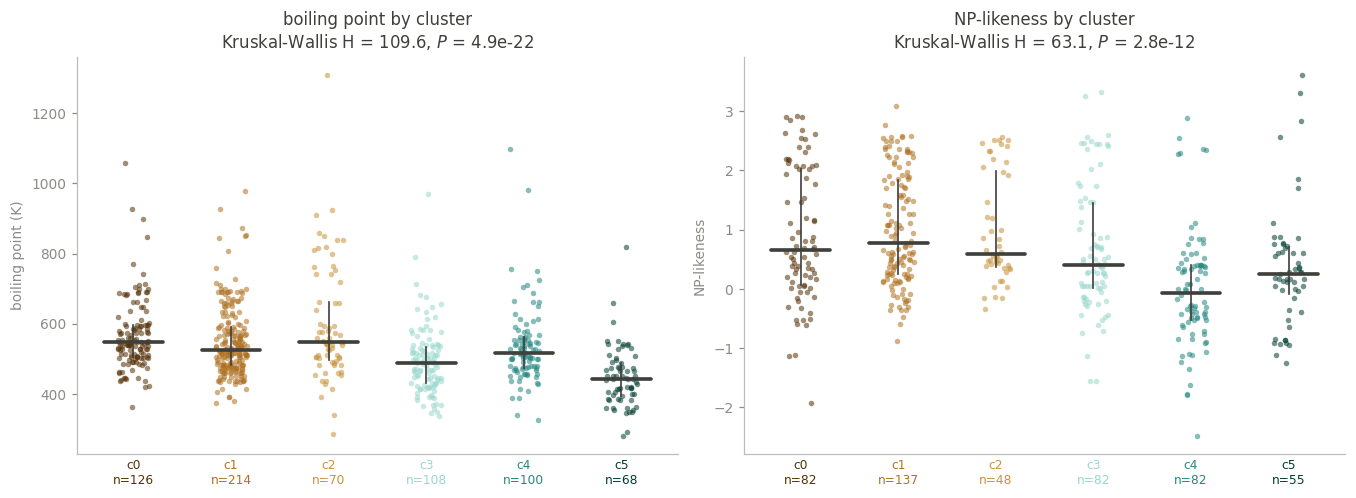


boiling point (K): medians by cluster
  cluster 0  n=126  median   546.85
  cluster 1  n=214  median   524.18
  cluster 2  n= 70  median   548.13
  cluster 3  n=108  median   486.40
  cluster 4  n=100  median   516.56
  cluster 5  n= 68  median   440.86
  extremes: cluster 2 vs 5  Mann-Whitney P = 4.08e-11  Cliff delta = +0.651

NP-likeness: medians by cluster
  cluster 0  n= 82  median     0.65
  cluster 1  n=137  median     0.77
  cluster 2  n= 48  median     0.59
  cluster 3  n= 82  median     0.41
  cluster 4  n= 82  median    -0.07
  cluster 5  n= 55  median     0.25
  extremes: cluster 1 vs 4  Mann-Whitney P = 4.65e-12  Cliff delta = +0.559


In [7]:
def cliffs(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if not len(a) or not len(b): return np.nan
    return float(np.sign(a[:, None] - b[None, :]).mean())


def by_cluster(col, label, ax, unit=""):
    data = [pd.to_numeric(P_.loc[P_.cluster == c, col], errors="coerce").dropna().values
            for c in range(K)]
    ok = [d for d in data if len(d) >= 3]
    H, p = kruskal(*ok) if len(ok) > 1 else (np.nan, np.nan)
    for c in range(K):
        d = data[c]
        if not len(d): continue
        xj = c + np.random.default_rng(c).uniform(-0.16, 0.16, len(d))
        ax.scatter(xj, d, s=13, color=THEME[c], alpha=0.55, lw=0)
        q1, med, q3 = np.percentile(d, [25, 50, 75])
        ax.plot([c-0.3, c+0.3], [med, med], color=INK, lw=2.4, solid_capstyle="round", zorder=5)
        ax.plot([c, c], [q1, q3], color=INK, lw=1.1, zorder=4)
    ax.set_xticks(range(K))
    ax.set_xticklabels([f"c{c}\nn={len(data[c])}" for c in range(K)], fontsize=8)
    for tl, c in zip(ax.get_xticklabels(), range(K)): tl.set_color(THEME[c])
    ax.set_ylabel(label + unit)
    ax.set_title(f"{label} by cluster\nKruskal-Wallis H = {H:.1f}, $P$ = {p:.2g}", color=INK)
    ax.tick_params(axis="x", length=0)
    return data, H, p


fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
tb, H_tb, p_tb = by_cluster("Tb_joback", "boiling point", axes[0], " (K)")
npl, H_np, p_np = by_cluster("np_likeness", "NP-likeness", axes[1])
plt.tight_layout(); plt.savefig(FIG / "X2_volatility_nplikeness.svg", bbox_inches="tight")
plt.savefig(FIG / "X2_volatility_nplikeness.png", bbox_inches="tight"); plt.show()

for name, data in [("boiling point (K)", tb), ("NP-likeness", npl)]:
    print(f"\n{name}: medians by cluster")
    meds = [(c, np.median(d)) for c, d in enumerate(data) if len(d)]
    for c, mv in meds: print(f"  cluster {c}  n={len(data[c]):3d}  median {mv:8.2f}")
    if len(meds) > 1:
        lo = min(meds, key=lambda t: t[1])[0]; hi = max(meds, key=lambda t: t[1])[0]
        u = mannwhitneyu(data[hi], data[lo]).pvalue
        print(f"  extremes: cluster {hi} vs {lo}  Mann-Whitney P = {u:.3g}  "
              f"Cliff delta = {cliffs(data[hi], data[lo]):+.3f}")

## 6 · Class I and Class II odorants on the map

Pairs with the polarity result in `reference_tree/02` section 9: the same three-way split, drawn
in chemical space instead of in descriptors.

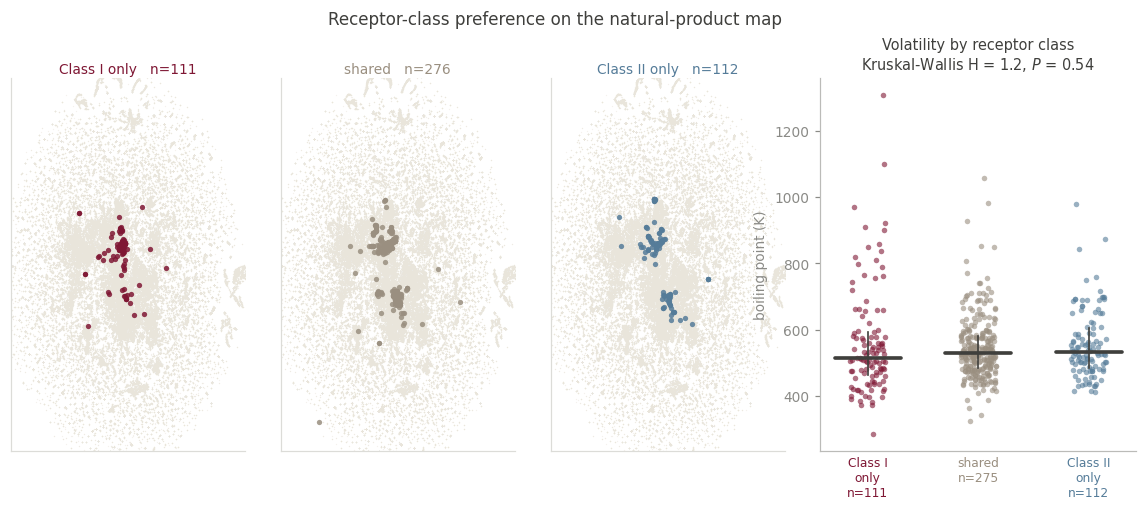

Class I only vs Class II only:  Mann-Whitney P = 0.295   Cliff delta = -0.081
  medians: Class I 515.4 K   Class II 532.2 K


In [8]:
# Same reason as the cluster figure: faceted, so hue never has to carry identity.
GC = {"Class I only": CLASS_I_COL, "shared": SHARED_COL, "Class II only": CLASS_II_COL}
groups = ["Class I only", "shared", "Class II only"]

fig = plt.figure(figsize=(13.2, 4.4))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.35], wspace=0.14)

for i, g in enumerate(groups):
    ax = fig.add_subplot(gs[0, i])
    ax.scatter(xy[sub,0], xy[sub,1], s=0.7, c="#e9e5db", alpha=0.5, lw=0, rasterized=True)
    m = P_.class_group == g
    ax.scatter(P_.x[m], P_.y[m], s=12, c=GC[g], alpha=0.85, lw=0, rasterized=True)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{g}   n={int(m.sum())}", fontsize=9, color=GC[g], pad=3)
    for sp in ax.spines.values(): sp.set_edgecolor("#dcdcd8")

ax = fig.add_subplot(gs[0, 3])
dat = [pd.to_numeric(P_.loc[P_.class_group == g, "Tb_joback"], errors="coerce").dropna().values
       for g in groups]
for i, (g, d) in enumerate(zip(groups, dat)):
    if not len(d): continue
    xj = i + np.random.default_rng(i).uniform(-0.16, 0.16, len(d))
    ax.scatter(xj, d, s=13, color=GC[g], alpha=0.6, lw=0)
    q1, med, q3 = np.percentile(d, [25, 50, 75])
    ax.plot([i-0.3, i+0.3], [med, med], color=INK, lw=2.4, zorder=5, solid_capstyle="round")
    ax.plot([i, i], [q1, q3], color=INK, lw=1.1, zorder=4)
ok = [d for d in dat if len(d) >= 3]
H, p = kruskal(*ok) if len(ok) > 1 else (np.nan, np.nan)
ax.set_xticks(range(3))
ax.set_xticklabels([g.replace(" only", "\nonly") + f"\nn={len(d)}" for g, d in zip(groups, dat)],
                   fontsize=8)
for tl, g in zip(ax.get_xticklabels(), groups): tl.set_color(GC[g])
ax.set_ylabel("boiling point (K)")
ax.set_title(f"Volatility by receptor class\nKruskal-Wallis H = {H:.1f}, $P$ = {p:.2g}",
             fontsize=9.5, color=INK)
ax.tick_params(axis="x", length=0)

fig.suptitle("Receptor-class preference on the natural-product map", fontsize=11, color=INK, y=1.02)
plt.savefig(FIG / "X3_class_in_chemspace.svg", bbox_inches="tight")
plt.savefig(FIG / "X3_class_in_chemspace.png", bbox_inches="tight"); plt.show()

if len(dat[0]) and len(dat[2]):
    print(f"Class I only vs Class II only:  Mann-Whitney P = "
          f"{mannwhitneyu(dat[0], dat[2]).pvalue:.3g}   "
          f"Cliff delta = {cliffs(dat[0], dat[2]):+.3f}")
    print(f"  medians: Class I {np.median(dat[0]):.1f} K   Class II {np.median(dat[2]):.1f} K")

## Notes

Read the map as **regions of natural-product space**, not as odour space — the axes carry no
perceptual meaning, and "island" is reserved for the kNN enrichment result in `chemspace/`.

Coverage is the first limit: only panel molecules COCONUT knows get coordinates, `Tb_joback` or
`np_likeness` at all, so every number here is on the natural-product subset of the panel and the
annotated molecules are the better-studied ones.

`Tb_joback` is a Joback group-contribution estimate applied well outside its fitting domain for
many of these molecules. It is a volatility *proxy*, and every volatility statement rests on it.

The within/between UMAP distance comparison is descriptive, not a test — UMAP distances are not
metric and the ratio is sensitive to the embedding. Use it to see whether clusters interleave, not
to quantify how much.